In [13]:
import pandas as pd

prices = pd.read_csv("../data/raw/world_market_prices.csv", index_col=0, parse_dates=True)

prices.tail()

,US,EU,INDIA,JAPAN,VIX
Date,,,,,
2026-03-06,6740.020020,5719.899902,24450.449219,55620.839844,29.490000
2026-03-09,6795.990234,5685.200195,24028.050781,52728.718750,25.500000
2026-03-10,6781.479980,5837.169922,24261.599609,54248.390625,24.930000
2026-03-11,6775.799805,5794.680176,23866.849609,55025.371094,24.230000
2026-03-12,6672.620117,5748.890137,23639.150391,54452.960938,27.290001


<AxesSubplot: xlabel='Date'>

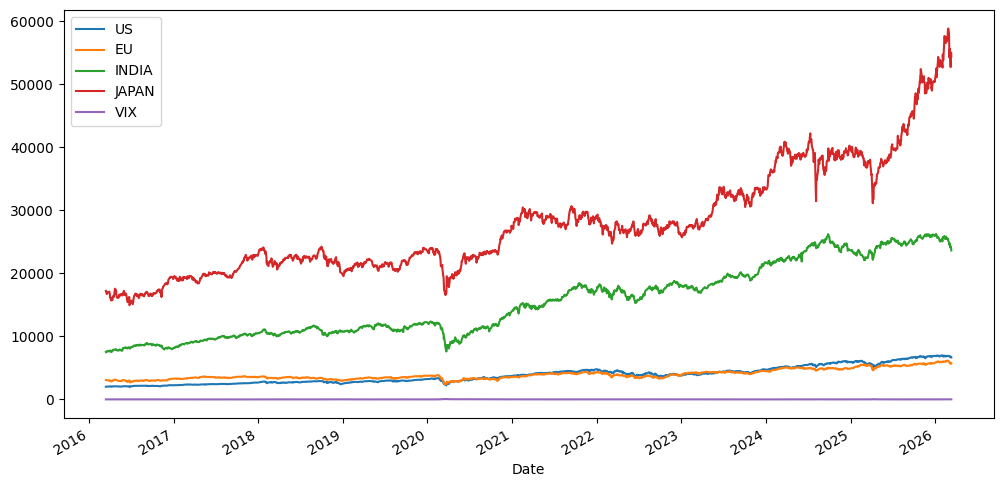

In [14]:
prices.plot(figsize=(12,6))

In [15]:
features = pd.read_csv("../data/processed/regime_features.csv", index_col=0, parse_dates=True)

features.head()

,global_equity_return,cross_sectional_dispersion,realized_vol_20,trend_ratio,vix_level,vix_return_5
Date,,,,,,
2016-08-26,-0.002043,0.007935,0.005214,0.022393,13.65,0.185403
2016-08-29,0.007025,0.011259,0.005348,0.022850,12.94,0.053166
2016-08-30,0.005949,0.008684,0.005322,0.022887,13.12,0.058055
2016-08-31,0.002380,0.005919,0.005244,0.023429,13.42,-0.002233
2016-09-01,-0.000223,0.001867,0.005218,0.023833,13.48,-0.011066


<AxesSubplot: xlabel='Date'>

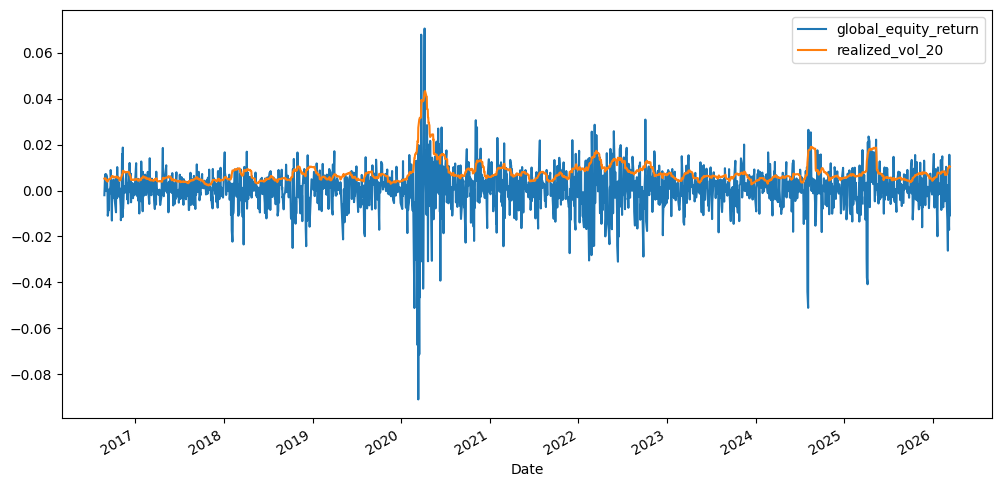

In [16]:
features[['global_equity_return','realized_vol_20']].plot(figsize=(12,6))

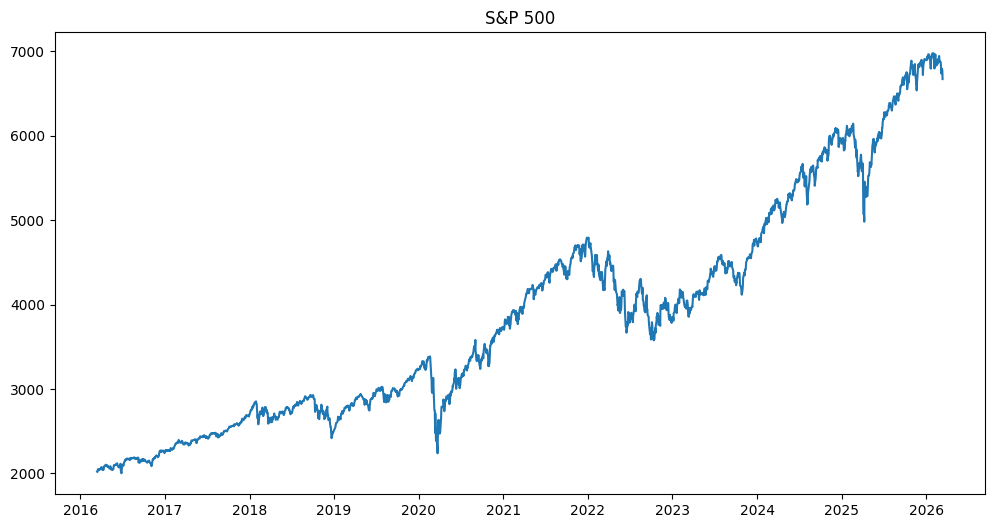

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(prices.index, prices["US"])
plt.title("S&P 500")
plt.show()

In [22]:
import sys
from pathlib import Path

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))

from src.current_world_market_regime import WorldMarketRegimeDetector

detector = WorldMarketRegimeDetector()
result = detector.detect()

transition_matrix = result.transition_matrix
transition_matrix

,Neutral / Stable,Bull / Low-Vol,Bear / Risk-Off,Bull / Low-Vol
Neutral / Stable,9.589323e-01,1.581360e-55,0.007629,0.033439
Bull / Low-Vol,6.648559e-24,9.856790e-01,0.010827,0.003494
Bear / Risk-Off,3.426304e-02,1.345347e-02,0.864943,0.087341
Bull / Low-Vol,1.680575e-02,1.320720e-02,0.006090,0.963897


<AxesSubplot: >

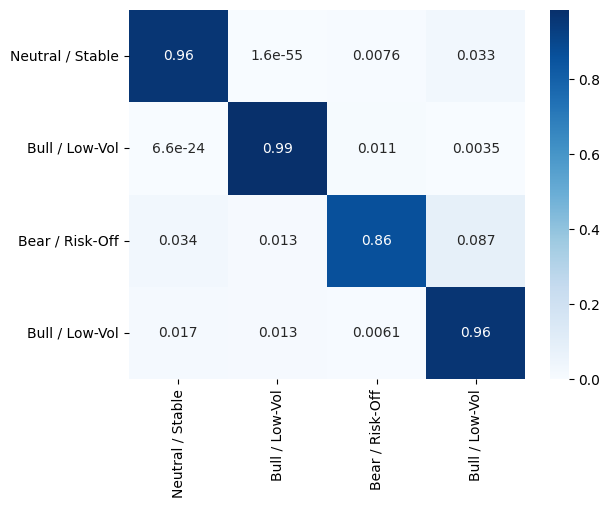

In [24]:
import seaborn as sns

sns.heatmap(transition_matrix, annot=True, cmap="Blues")


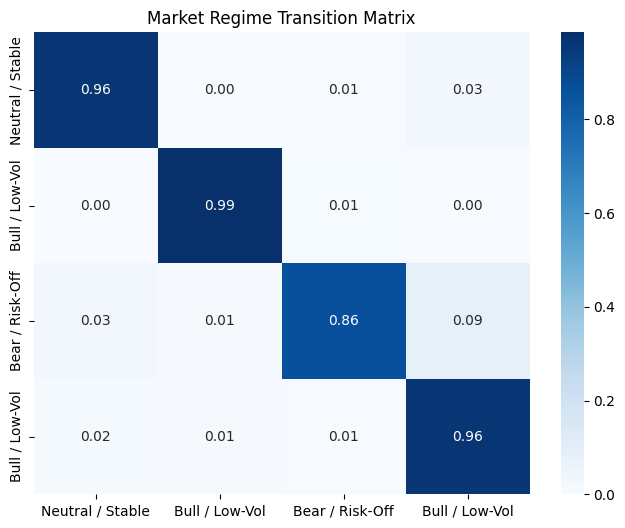

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    transition_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Market Regime Transition Matrix")
plt.show()